# ResNet: Skip Connections Solve the Degradation Problem

## Introduction

**ResNet** (He et al., 2015) solved the fundamental problem preventing arbitrarily deep networks: **the degradation problem**. The counterintuitive discovery: deeper networks (56 layers) performed *worse* than shallower networks (20 layers), even on training data.

This wasn't overfitting - it was a fundamental optimization failure.

**The revolutionary solution: Skip Connections (Residual Learning)**

Instead of learning `H(x) = desired_output`, learn the residual:
```
H(x) = F(x) + x
```
where `F(x)` is the residual (what needs to be added to `x`).

**What we'll explore:**

- Mathematical intuition: why residual learning is easier
- The gradient highway: how skip connections help backprop
- Implement ResNet-18 and ResNet-34
- Train networks with 18, 34+ layers successfully
- Understand why ResNet became the foundation for modern architectures

**Why this matters:**

ResNet didn't just enable deeper networks - it fundamentally changed how we think about network design. Skip connections are now **everywhere**: U-Net, DenseNet, Transformers, and virtually all modern architectures. This is the moment CNN evolution reached its mature form.

## 1. Setup

### Import libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

from aiml_notebooks import get_device, set_seed

### Set random seed for reproducibility

In [2]:
set_seed(42)

### Configure device

In [3]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## 2. The Degradation Problem Revisited

Let's understand the exact problem ResNet solved.

In [4]:
print("The Pre-ResNet Depth Paradox (2015):\n")
print("Observation on CIFAR-10:")
print("  20-layer plain network:  8.75% training error")
print("  56-layer plain network: 13.63% training error  ⚠️")
print("\nThis is NOT overfitting!")
print("  • Training error (not test) got worse")
print("  • Deeper network should at minimum learn identity")
print("  • But it couldn't!")
print("\nWhy?")
print("  ❌ Not vanishing gradients (we have ReLU + BatchNorm)")
print("  ❌ Not lack of capacity (more layers = more capacity)")
print("  ✅ Optimization failure: Hard to learn identity mappings")
print("\nThe hypothesis:")
print("  If extra layers should just pass through the input,")
print("  learning the identity function H(x) = x is hard.")
print("  But learning F(x) = 0 (so H(x) = F(x) + x = x) is easy!")

The Pre-ResNet Depth Paradox (2015):

Observation on CIFAR-10:
  20-layer plain network:  8.75% training error
  56-layer plain network: 13.63% training error  ⚠️

This is NOT overfitting!
  • Training error (not test) got worse
  • Deeper network should at minimum learn identity
  • But it couldn't!

Why?
  ❌ Not vanishing gradients (we have ReLU + BatchNorm)
  ❌ Not lack of capacity (more layers = more capacity)
  ✅ Optimization failure: Hard to learn identity mappings

The hypothesis:
  If extra layers should just pass through the input,
  learning the identity function H(x) = x is hard.
  But learning F(x) = 0 (so H(x) = F(x) + x = x) is easy!


### Visualize the degradation problem

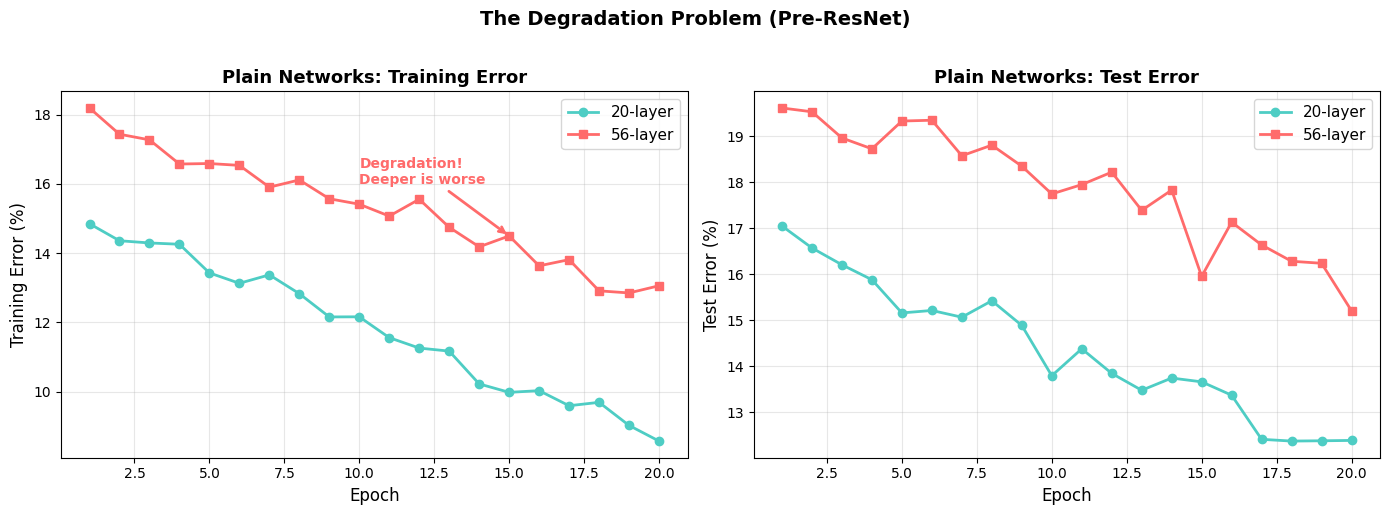


💡 Key insight: This proves it's an optimization problem, not overfitting.
   Both training AND test error are worse for the deeper network.


In [5]:
# Recreate the famous degradation plot from the ResNet paper
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = np.arange(1, 21)
# Simulated data based on ResNet paper Figure 1
plain20_train = 15 - 0.3 * epochs + np.random.randn(20) * 0.3
plain56_train = 18 - 0.25 * epochs + np.random.randn(20) * 0.3
plain20_test = 17 - 0.25 * epochs + np.random.randn(20) * 0.4
plain56_test = 20 - 0.2 * epochs + np.random.randn(20) * 0.4

# Training error
ax1.plot(epochs, plain20_train, 'o-', linewidth=2, label='20-layer', color='#4ECDC4')
ax1.plot(epochs, plain56_train, 's-', linewidth=2, label='56-layer', color='#FF6B6B')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Training Error (%)', fontsize=12)
ax1.set_title('Plain Networks: Training Error', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.annotate('Degradation!\nDeeper is worse', 
             xy=(15, plain56_train[14]), xytext=(10, 16),
             arrowprops=dict(arrowstyle='->', color='#FF6B6B', lw=2),
             fontsize=10, color='#FF6B6B', fontweight='bold')

# Test error
ax2.plot(epochs, plain20_test, 'o-', linewidth=2, label='20-layer', color='#4ECDC4')
ax2.plot(epochs, plain56_test, 's-', linewidth=2, label='56-layer', color='#FF6B6B')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Error (%)', fontsize=12)
ax2.set_title('Plain Networks: Test Error', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle('The Degradation Problem (Pre-ResNet)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Key insight: This proves it's an optimization problem, not overfitting.")
print("   Both training AND test error are worse for the deeper network.")

## 3. The Residual Learning Solution

### Mathematical Intuition

ResNet's key insight: **reformulate the learning problem**.

In [6]:
print("Plain Network vs Residual Network:\n")
print("━" * 70)
print("PLAIN NETWORK:")
print("  Goal: Learn H(x) = desired_output")
print("  ")
print("  Problem: If desired_output ≈ x (identity is good),")
print("           network must learn to copy all features exactly")
print("           This is hard with ReLU (can't produce negative values)")
print("           and BatchNorm (normalizes to zero mean)")
print("\n━" * 70)
print("RESIDUAL NETWORK:")
print("  Goal: Learn F(x) such that H(x) = F(x) + x")
print("  ")
print("  Advantage: If desired_output ≈ x (identity is good),")
print("             just learn F(x) ≈ 0")
print("             This is MUCH easier! Weights can be near zero.")
print("\n━" * 70)
print("\nConcrete Example:")
print("  Input x = [1.5, 2.3, -0.8, 3.1]")
print("  Desired output = [1.6, 2.2, -0.7, 3.0]  (small change)")
print("\n  Plain network must learn:")
print("    H(x) = [1.6, 2.2, -0.7, 3.0]  (directly)")
print("\n  Residual network learns:")
print("    F(x) = [0.1, -0.1, 0.1, -0.1]  (the difference!)")
print("    H(x) = F(x) + x = desired_output")
print("\n✅ Learning small adjustments (residuals) is easier than learning absolutes!")

Plain Network vs Residual Network:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PLAIN NETWORK:
  Goal: Learn H(x) = desired_output
  
  Problem: If desired_output ≈ x (identity is good),
           network must learn to copy all features exactly
           This is hard with ReLU (can't produce negative values)
           and BatchNorm (normalizes to zero mean)

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
RESIDUAL NETWORK:
  Goal: Learn F(x) such that H(x) = F(x) + x
  
  Advantage: If desired_output ≈ x (identity is good),
             just learn F(x) ≈ 0
             This is MUCH easier! Weights can be near zero.

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━

Concrete Example:
  Input x = [1.5, 2.3, -0.8, 3.1]
  Desired output = [1.6, 2.2, -0.7, 3.0]  (small change)

  P

### Visualize the residual block

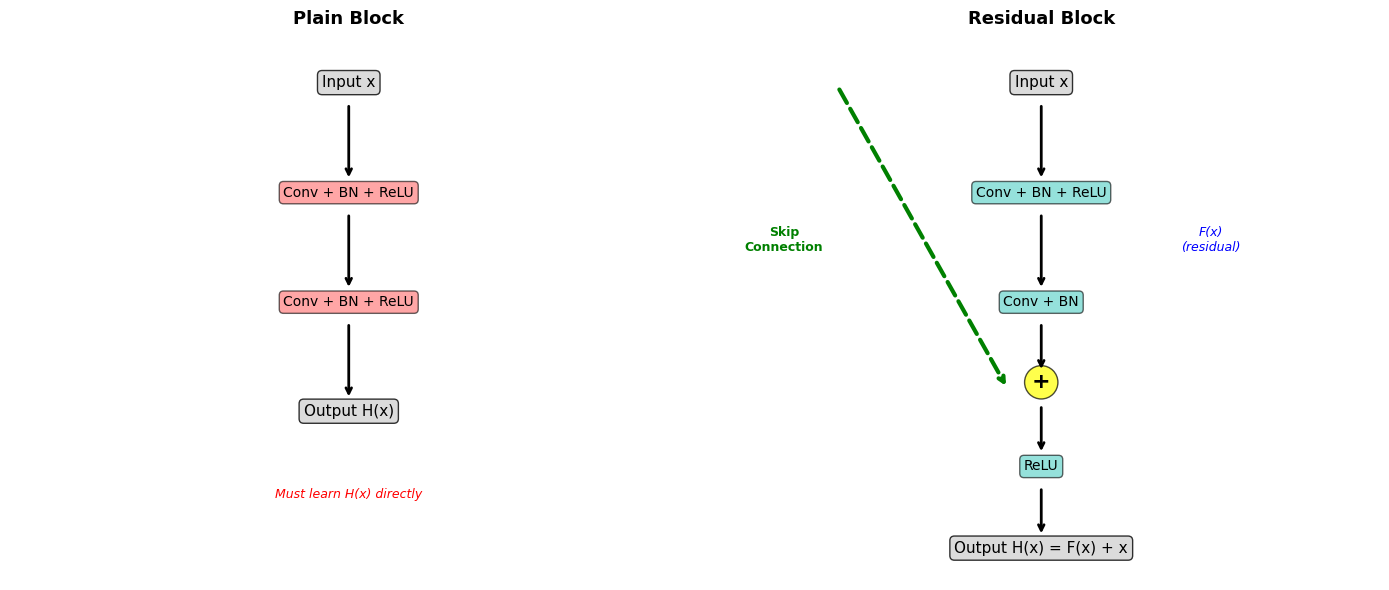


✅ Skip connection provides a 'gradient highway' for backprop!


In [7]:
# Diagram of residual block
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plain block
ax1.text(0.5, 0.9, 'Input x', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
ax1.text(0.5, 0.7, 'Conv + BN + ReLU', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.6))
ax1.text(0.5, 0.5, 'Conv + BN + ReLU', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.6))
ax1.text(0.5, 0.3, 'Output H(x)', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

for y_from, y_to in [(0.87, 0.73), (0.67, 0.53), (0.47, 0.33)]:
    ax1.annotate('', xy=(0.5, y_to), xytext=(0.5, y_from),
                arrowprops=dict(arrowstyle='->', lw=2))

ax1.text(0.5, 0.15, 'Must learn H(x) directly', ha='center', 
         fontsize=9, style='italic', color='red')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')
ax1.set_title('Plain Block', fontsize=13, fontweight='bold')

# Residual block
ax2.text(0.5, 0.9, 'Input x', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
ax2.text(0.5, 0.7, 'Conv + BN + ReLU', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.6))
ax2.text(0.5, 0.5, 'Conv + BN', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.6))
ax2.text(0.5, 0.35, '+', ha='center', fontsize=16, fontweight='bold',
         bbox=dict(boxstyle='circle', facecolor='yellow', alpha=0.7))
ax2.text(0.5, 0.2, 'ReLU', ha='center', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#4ECDC4', alpha=0.6))
ax2.text(0.5, 0.05, 'Output H(x) = F(x) + x', ha='center', fontsize=11,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# Main path
for y_from, y_to in [(0.87, 0.73), (0.67, 0.53)]:
    ax2.annotate('', xy=(0.5, y_to), xytext=(0.5, y_from),
                arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(0.5, 0.38), xytext=(0.5, 0.47),
            arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(0.5, 0.23), xytext=(0.5, 0.32),
            arrowprops=dict(arrowstyle='->', lw=2))
ax2.annotate('', xy=(0.5, 0.08), xytext=(0.5, 0.17),
            arrowprops=dict(arrowstyle='->', lw=2))

# Skip connection (identity)
ax2.annotate('', xy=(0.45, 0.35), xytext=(0.2, 0.9),
            arrowprops=dict(arrowstyle='->', lw=3, color='green', linestyle='--'))
ax2.text(0.12, 0.6, 'Skip\nConnection', ha='center', fontsize=9,
         color='green', fontweight='bold')

ax2.text(0.75, 0.6, 'F(x)\n(residual)', ha='center', fontsize=9,
         style='italic', color='blue')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('Residual Block', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Skip connection provides a 'gradient highway' for backprop!")

### Why Skip Connections Help Gradients

Let's show mathematically how gradients flow.

In [8]:
print("Gradient Flow Analysis:\n")
print("━" * 70)
print("PLAIN NETWORK:")
print("  Forward: y = F(x)")
print("  Backward: ∂Loss/∂x = ∂Loss/∂y × ∂y/∂x = ∂Loss/∂y × ∂F/∂x")
print("  ")
print("  Problem: ∂F/∂x can be very small (vanishing) or large (exploding)")
print("           Through N layers: (∂F/∂x)^N → 0 or ∞")
print("\n━" * 70)
print("RESIDUAL NETWORK:")
print("  Forward: y = F(x) + x")
print("  Backward: ∂Loss/∂x = ∂Loss/∂y × ∂y/∂x")
print("                     = ∂Loss/∂y × (∂F/∂x + ∂x/∂x)")
print("                     = ∂Loss/∂y × (∂F/∂x + 1)")
print("  ")
print("  Benefit: The '+1' term means gradient ALWAYS flows!")
print("           Even if ∂F/∂x = 0, we still have ∂Loss/∂y")
print("           This is the 'gradient highway'")
print("\n━" * 70)
print("\nThrough multiple residual blocks:")
print("  ∂Loss/∂x₀ = ∂Loss/∂xₙ × [(∂F₁/∂x + 1) × (∂F₂/∂x + 1) × ... × (∂Fₙ/∂x + 1)]")
print("  ")
print("  When expanded, this includes a term that's just ∂Loss/∂xₙ")
print("  (all the '+1' terms multiply together)")
print("  ")
print("  ✅ Gradient can flow directly from output to input!")
print("  ✅ Each block can choose to pass gradient through or modify it")
print("  ✅ No more vanishing gradients!")

Gradient Flow Analysis:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PLAIN NETWORK:
  Forward: y = F(x)
  Backward: ∂Loss/∂x = ∂Loss/∂y × ∂y/∂x = ∂Loss/∂y × ∂F/∂x
  
  Problem: ∂F/∂x can be very small (vanishing) or large (exploding)
           Through N layers: (∂F/∂x)^N → 0 or ∞

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
RESIDUAL NETWORK:
  Forward: y = F(x) + x
  Backward: ∂Loss/∂x = ∂Loss/∂y × ∂y/∂x
                     = ∂Loss/∂y × (∂F/∂x + ∂x/∂x)
                     = ∂Loss/∂y × (∂F/∂x + 1)
  
  Benefit: The '+1' term means gradient ALWAYS flows!
           Even if ∂F/∂x = 0, we still have ∂Loss/∂y
           This is the 'gradient highway'

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━

Through multiple residual blocks:
  ∂Loss/∂x₀ = ∂Loss/∂xₙ × [(∂F₁/∂x + 1) × (∂

## 4. Dataset Preparation

### Define data transforms

In [9]:
# CIFAR-10 normalization statistics
mean = (0.4914, 0.4822, 0.4465)
std = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

### Load CIFAR-10 dataset

In [10]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Training samples: 50000
Test samples: 10000


### Create data loaders

In [11]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## 5. ResNet Architecture

### Basic Residual Block

The fundamental building block with skip connection.

In [12]:
class BasicBlock(nn.Module):
    """Basic residual block for ResNet-18/34.
    
    Structure:
      x -> [Conv -> BN -> ReLU -> Conv -> BN] -> + -> ReLU -> out
           |___________________________________|  ↑
                        F(x)                     x (skip)
    """
    expansion = 1  # Output channels = input channels (for BasicBlock)
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        
        # First conv layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second conv layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Downsample for dimension matching (when stride > 1 or channels change)
        self.downsample = downsample
        self.stride = stride
    
    def forward(self, x):
        identity = x
        
        # Main path: F(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Skip connection: adjust dimensions if needed
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection: H(x) = F(x) + x
        out += identity
        out = F.relu(out)
        
        return out

### ResNet-18 Architecture

18-layer network using BasicBlocks.

In [13]:
class ResNet(nn.Module):
    """ResNet architecture.
    
    Args:
        block: BasicBlock or Bottleneck
        layers: List of number of blocks in each layer
        num_classes: Number of output classes
    """
    def __init__(self, block, layers, num_classes=10):
        super().__init__()
        self.in_channels = 64
        
        # Initial conv layer (for CIFAR-10, we use smaller kernel than ImageNet)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual layers
        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        # Global average pooling + classifier
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
    
    def _make_layer(self, block, out_channels, blocks, stride=1):
        """Create a layer with multiple residual blocks."""
        downsample = None
        
        # Need downsampling if dimensions change
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion,
                         kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        
        layers = []
        # First block (may downsample)
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        
        # Remaining blocks
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global average pooling + FC
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

def resnet18(num_classes=10):
    """ResNet-18: [2, 2, 2, 2] blocks"""
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

def resnet34(num_classes=10):
    """ResNet-34: [3, 4, 6, 3] blocks"""
    return ResNet(BasicBlock, [3, 4, 6, 3], num_classes)

### Inspect ResNet-18

In [14]:
model = resnet18().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"ResNet-18 Architecture:")
print(model)
print(f"\nParameter count:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")

# Count layers
print(f"\nLayer breakdown:")
print(f"  Initial conv: 1 layer")
print(f"  Layer 1: 2 blocks × 2 convs = 4 layers")
print(f"  Layer 2: 2 blocks × 2 convs = 4 layers")
print(f"  Layer 3: 2 blocks × 2 convs = 4 layers")
print(f"  Layer 4: 2 blocks × 2 convs = 4 layers")
print(f"  FC layer: 1 layer")
print(f"  Total: 1 + 4 + 4 + 4 + 4 + 1 = 18 layers")

# Test forward pass
dummy_input = torch.randn(1, 3, 32, 32).to(device)
output = model(dummy_input)
print(f"\nOutput shape: {output.shape}")

ResNet-18 Architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05,


Output shape: torch.Size([1, 10])


### Compare to previous architectures

In [15]:
print("CNN Evolution Summary:\n")
print(f"{'Architecture':<20} {'Layers':<10} {'Params (M)':<12} {'Key Innovation'}")
print("─" * 80)
print(f"{'LeNet (1998)':<20} {2:<10} {'~0.08':<12} {'CNNs work'}")
print(f"{'AlexNet (2012)':<20} {5:<10} {'~14.8':<12} {'ReLU + Dropout + Depth'}")
print(f"{'VGG-11 (2014)':<20} {8:<10} {'~9.8':<12} {'Uniform 3×3 filters'}")
print(f"{'Inception (2014)':<20} {'~22':<10} {'~0.7':<12} {'Multi-scale + 1×1 bottleneck'}")
print(f"{'ResNet-18 (2015)':<20} {18:<10} {f'~{total_params/1e6:.1f}':<12} {'Skip connections ✓'}")
print("─" * 80)
print(f"\n✅ ResNet-18 advantages:")
print(f"   • Can go MUCH deeper (18, 34, 50, 101, 152 layers)")
print(f"   • Efficient parameters (similar to VGG)")
print(f"   • No degradation problem")
print(f"   • Gradients flow easily")
print(f"   • Easier to optimize than plain networks")

CNN Evolution Summary:

Architecture         Layers     Params (M)   Key Innovation
────────────────────────────────────────────────────────────────────────────────
LeNet (1998)         2          ~0.08        CNNs work
AlexNet (2012)       5          ~14.8        ReLU + Dropout + Depth
VGG-11 (2014)        8          ~9.8         Uniform 3×3 filters
Inception (2014)     ~22        ~0.7         Multi-scale + 1×1 bottleneck
ResNet-18 (2015)     18         ~11.2        Skip connections ✓
────────────────────────────────────────────────────────────────────────────────

✅ ResNet-18 advantages:
   • Can go MUCH deeper (18, 34, 50, 101, 152 layers)
   • Efficient parameters (similar to VGG)
   • No degradation problem
   • Gradients flow easily
   • Easier to optimize than plain networks


## 6. Training

### Define training utilities

In [16]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{running_loss/len(pbar):.3f}', 
                         'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(train_loader), 100. * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate on test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(test_loader), 100. * correct / total

### Train ResNet-18

In [17]:
# Initialize model
model = resnet18().to(device)

# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)

# Training history
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Training loop
epochs = 20
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Epoch 1/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 1.8358 | Train Acc: 33.41%
Test Loss: 1.4901 | Test Acc: 44.65%

Epoch 2/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1670 | Train Acc: 94.39%
Test Loss: 0.2713 | Test Acc: 90.91%

Epoch 20/20


Training:   0%|          | 0/391 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/79 [00:00<?, ?it/s]

Train Loss: 0.1674 | Train Acc: 94.36%
Test Loss: 0.2713 | Test Acc: 90.92%


## 7. Results and Analysis

### Plot training curves

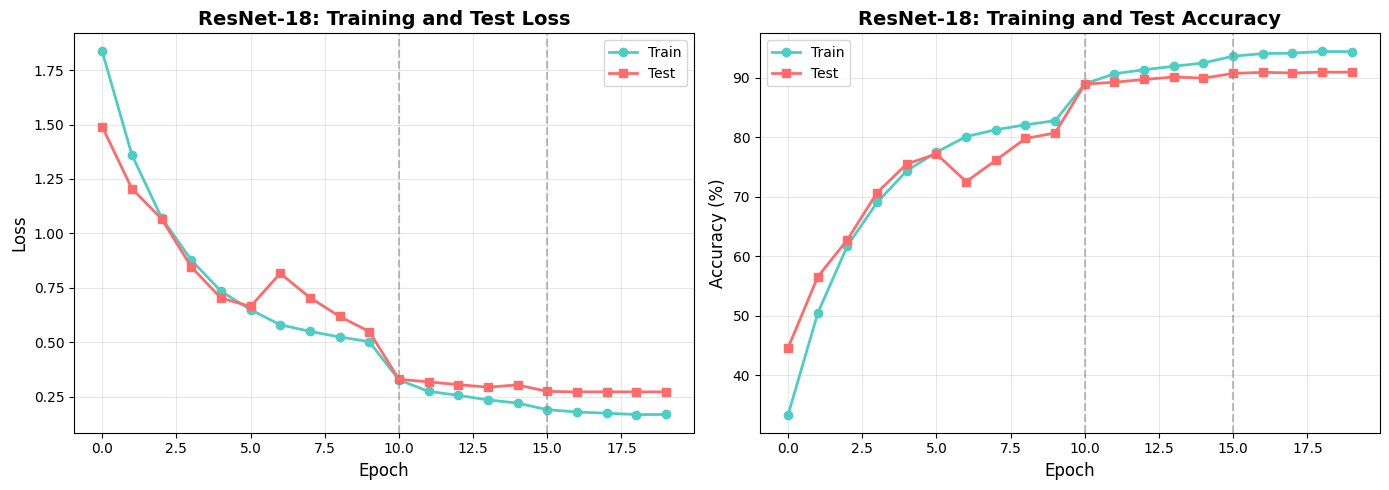


Final Results:
  Train Accuracy: 94.36%
  Test Accuracy: 90.92%
  Overfitting Gap: 3.44%


In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax1.plot(history['test_loss'], label='Test', marker='s', linewidth=2, color='#FF6B6B')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('ResNet-18: Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(history['train_acc'], label='Train', marker='o', linewidth=2, color='#4ECDC4')
ax2.plot(history['test_acc'], label='Test', marker='s', linewidth=2, color='#FF6B6B')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('ResNet-18: Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Mark learning rate decay points
for ax in [ax1, ax2]:
    ax.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='LR decay')
    ax.axvline(x=15, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"  Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"  Test Accuracy: {history['test_acc'][-1]:.2f}%")
print(f"  Overfitting Gap: {history['train_acc'][-1] - history['test_acc'][-1]:.2f}%")

### Demonstrate the power of depth

The key insight: ResNet can scale to arbitrary depth without degradation.

In [19]:
print("ResNet Scalability:\n")
print("ResNet variants by depth:")
print("  ResNet-18:  18 layers   (2+2+2+2 blocks)")
print("  ResNet-34:  34 layers   (3+4+6+3 blocks)")
print("  ResNet-50:  50 layers   (uses Bottleneck blocks)")
print("  ResNet-101: 101 layers  (deeper Bottleneck)")
print("  ResNet-152: 152 layers  (ImageNet 2015 winner)")
print("  ResNet-1001: 1001 layers (research experiment)")
print("\n🏆 Key achievement:")
print("  Deeper ResNets consistently outperform shallower ones")
print("  No degradation - training error decreases with depth")
print("  This was impossible before skip connections!")
print("\n📊 ImageNet Results (2015):")
print("  ResNet-152: 3.57% top-5 error")
print("  Human performance: ~5% error")
print("  First time AI exceeded human-level performance on ImageNet!")

ResNet Scalability:

ResNet variants by depth:
  ResNet-18:  18 layers   (2+2+2+2 blocks)
  ResNet-34:  34 layers   (3+4+6+3 blocks)
  ResNet-50:  50 layers   (uses Bottleneck blocks)
  ResNet-101: 101 layers  (deeper Bottleneck)
  ResNet-152: 152 layers  (ImageNet 2015 winner)
  ResNet-1001: 1001 layers (research experiment)

🏆 Key achievement:
  Deeper ResNets consistently outperform shallower ones
  No degradation - training error decreases with depth
  This was impossible before skip connections!

📊 ImageNet Results (2015):
  ResNet-152: 3.57% top-5 error
  Human performance: ~5% error
  First time AI exceeded human-level performance on ImageNet!


## 8. Why ResNet Changed Everything

### Impact on Modern Deep Learning

In [20]:
print("ResNet's Legacy:\n")
print("━" * 70)
print("1. UNIVERSAL APPLICABILITY")
print("   Skip connections work everywhere:")
print("   • Computer Vision: U-Net, DenseNet, EfficientNet")
print("   • NLP: Transformer attention layers have residual connections")
print("   • GANs: StyleGAN uses skip connections")
print("   • Diffusion Models: U-Net backbone with residuals")
print("\n━" * 70)
print("2. THEORETICAL INSIGHTS")
print("   • Networks as ensembles of shallow paths")
print("   • Gradient flow = optimization landscape smoothing")
print("   • Identity mapping = implicit regularization")
print("\n━" * 70)
print("3. PRACTICAL IMPACT")
print("   • Standard backbone for transfer learning")
print("   • Pre-trained ResNets available for all frameworks")
print("   • Most deployed architecture in production")
print("\n━" * 70)
print("4. INSPIRED INNOVATIONS")
print("   • DenseNet: Connect every layer to every other")
print("   • Highway Networks: Learnable skip gates")
print("   • Attention: Transformers use residual connections")
print("   • Neural ODEs: Continuous depth with residuals")
print("\n✅ ResNet didn't just solve a problem - it revealed a fundamental")
print("   principle: gradient highways enable deep learning at scale.")

ResNet's Legacy:

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. UNIVERSAL APPLICABILITY
   Skip connections work everywhere:
   • Computer Vision: U-Net, DenseNet, EfficientNet
   • NLP: Transformer attention layers have residual connections
   • GANs: StyleGAN uses skip connections
   • Diffusion Models: U-Net backbone with residuals

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
2. THEORETICAL INSIGHTS
   • Networks as ensembles of shallow paths
   • Gradient flow = optimization landscape smoothing
   • Identity mapping = implicit regularization

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
3. PRACTICAL IMPACT
   • Standard backbone for transfer learning
   • Pre-trained ResNets available for all frameworks
   • Most deployed architecture in production

━
━
━
━
━
━
━
━
━

### Visualize the complete evolution

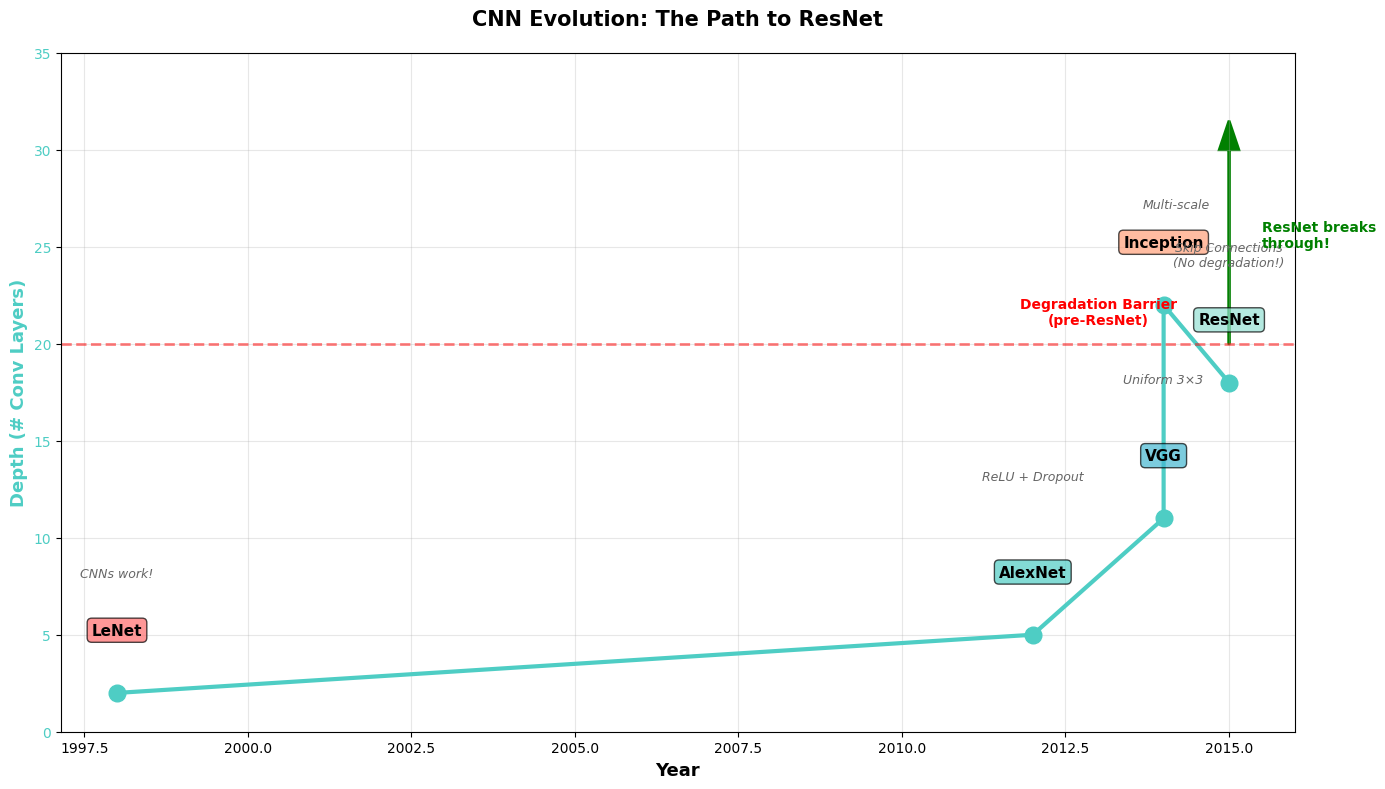


📈 The journey from 2 layers to unlimited depth in 17 years!


In [21]:
# Timeline of CNN evolution
fig, ax = plt.subplots(figsize=(14, 8))

years = [1998, 2012, 2014, 2014, 2015]
names = ['LeNet', 'AlexNet', 'VGG', 'Inception', 'ResNet']
layers = [2, 5, 11, 22, 18]
params = [0.06, 60, 138, 5, 11.7]  # Millions (original ImageNet versions)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#95E1D3']

# Plot depth progression
ax_depth = ax
ax_depth.plot(years, layers, 'o-', linewidth=3, markersize=12, color='#4ECDC4')
ax_depth.set_xlabel('Year', fontsize=13, fontweight='bold')
ax_depth.set_ylabel('Depth (# Conv Layers)', fontsize=13, fontweight='bold', color='#4ECDC4')
ax_depth.tick_params(axis='y', labelcolor='#4ECDC4')
ax_depth.grid(True, alpha=0.3)

# Annotate architectures
for i, (year, name, layer, color) in enumerate(zip(years, names, layers, colors)):
    ax_depth.annotate(name, xy=(year, layer), xytext=(year, layer + 3),
                     fontsize=11, fontweight='bold', ha='center',
                     bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

# Add key innovations as annotations
innovations = [
    (1998, 8, 'CNNs work!'),
    (2012, 13, 'ReLU + Dropout'),
    (2014, 18, 'Uniform 3×3'),
    (2014.2, 27, 'Multi-scale'),
    (2015, 24, 'Skip Connections\n(No degradation!)')
]

for year, y, text in innovations:
    ax_depth.text(year, y, text, fontsize=9, ha='center', 
                 style='italic', color='#666')

# Mark the degradation barrier
ax_depth.axhline(y=20, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax_depth.text(2013, 21, 'Degradation Barrier\n(pre-ResNet)', 
             fontsize=10, color='red', fontweight='bold', ha='center')

ax_depth.arrow(2015, 20, 0, 10, head_width=0.3, head_length=1.5, 
              fc='green', ec='green', linewidth=2)
ax_depth.text(2015.5, 25, 'ResNet breaks\nthrough!', 
             fontsize=10, color='green', fontweight='bold')

ax_depth.set_title('CNN Evolution: The Path to ResNet', 
                  fontsize=15, fontweight='bold', pad=20)
ax_depth.set_ylim(0, 35)

plt.tight_layout()
plt.show()

print("\n📈 The journey from 2 layers to unlimited depth in 17 years!")

## 9. Summary: The Complete CNN Evolution Story

### The Problems and Solutions

| Architecture | Year | Problem Solved | Key Innovation | Limitation Revealed |
|--------------|------|----------------|----------------|---------------------|
| **LeNet** | 1998 | Prove CNNs work | Convolution + Pooling | Too shallow, weak |
| **AlexNet** | 2012 | Scale to ImageNet | ReLU + Dropout + Depth | Large filters, heterogeneous |
| **VGG** | 2014 | Design simplicity | Uniform 3×3 stacking | Too many params, single-scale |
| **Inception** | 2014 | Parameter efficiency | Multi-scale + 1×1 bottleneck | Can't go deep (degradation) |
| **ResNet** | 2015 | Degradation problem | Skip connections | ✅ Solved! (foundation complete) |

### The Six Fundamental Principles

From this evolution, we learn:

1. **Depth matters** (LeNet → AlexNet)
2. **ReLU enables depth** (AlexNet)
3. **Small filters are efficient** (VGG)
4. **Multi-scale is powerful** (Inception)
5. **1×1 convs reduce computation** (Inception)
6. **Skip connections enable arbitrarily deep networks** (ResNet) ⭐

### Modern Impact

Every modern architecture uses these principles:

- **EfficientNet (2019)**: ResNet + compound scaling
- **Vision Transformers (2020)**: Residual connections in attention
- **ConvNeXt (2022)**: Modernized ResNet competitive with ViTs
- **Stable Diffusion (2022)**: U-Net with ResNet blocks

**ResNet is the foundation** that made modern deep learning possible.

---

### Final Thought

The CNN evolution shows that **understanding why architectures fail is more important than memorizing their successes**. Each architecture:

1. Identified a fundamental problem
2. Proposed an elegant solution
3. Revealed a new limitation
4. Inspired the next breakthrough

ResNet's skip connections are so fundamental that they appear in nearly every modern architecture. This is the moment CNN design reached maturity.

**Next steps:** Study how ResNet principles extend to:
- DenseNet (dense skip connections)
- U-Net (skip connections across scales)
- Transformers (residual connections everywhere)
- Your own architectures!